# **1. Perkenalan Dataset**


## **Sumber Dataset:**
Dataset ini berisi transaksi dari berbagai mall di Turki.

## **Deskripsi Dataset:**
Dataset ini mencatat informasi transaksi pelanggan di berbagai pusat perbelanjaan, mencakup detail produk, metode pembayaran, dan demografi pelanggan.

## **Fitur-fitur:**
1. **invoice_no** - Nomor invoice transaksi (unique identifier)
2. **customer_id** - ID unik pelanggan
3. **gender** - Jenis kelamin (Female/Male)
4. **age** - Usia pelanggan (18-69 tahun)
5. **category** - Kategori produk (Clothing, Shoes, Books, dll)
6. **quantity** - Jumlah item yang dibeli (1-5)
7. **price** - Harga per item (dalam mata uang lokal)
8. **payment_method** - Metode pembayaran (Cash, Credit Card, Debit Card)
9. **invoice_date** - Tanggal transaksi
10. **shopping_mall** - Nama mall tempat transaksi

## **Target Variable:**
- **Total Amount = quantity × price** (menghasilkan total belanja)

## **Tipe Masalah:**
**Regression** (memprediksi total amount belanja)


In [27]:
# Install kaggle CLI
!pip install kaggle

In [28]:
# Download dataset (Customer Shopping Dataset)
!kaggle datasets download -d mehmettahiraslan/customer-shopping-dataset

# Extract ke folder dataset_raw
!unzip customer-shopping-dataset.zip -d customer_shopping_data_raw/

Dataset URL: https://www.kaggle.com/datasets/mehmettahiraslan/customer-shopping-dataset
License(s): CC0-1.0
customer-shopping-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  customer-shopping-dataset.zip
  inflating: customer_shopping_data_raw/customer_shopping_data.csv  


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Setting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Library berhasil diimport!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Library berhasil diimport!
Pandas version: 2.2.2
NumPy version: 2.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [39]:
df = pd.read_csv('customer_shopping_data_raw/customer_shopping_data.csv')

print("="*50)
print("5 BARIS PERTAMA DATASET:")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("INFORMASI DATASET:")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("STATISTIK DESKRIPTIF:")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print("CEK MISSING VALUES:")
print("="*50)
print(df.isnull().sum())

# Tambahan: Cek unique values untuk categorical columns
print("\n" + "="*50)
print("UNIQUE VALUES PER KOLOM KATEGORIKAL:")
print("="*50)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(f"  Sample: {df[col].unique()[:5]}")
    print()

5 BARIS PERTAMA DATASET:
  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Clothing         1   300.08   
3    I173702     C988172  Female   66     Shoes         5  3000.85   
4    I337046     C189076  Female   53     Books         4    60.60   

  payment_method invoice_date   shopping_mall  
0    Credit Card     5/8/2022          Kanyon  
1     Debit Card   12/12/2021  Forum Istanbul  
2           Cash    9/11/2021       Metrocity  
3    Credit Card   16/05/2021    Metropol AVM  
4           Cash   24/10/2021          Kanyon  

INFORMASI DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [40]:
# Membuat target variable: Total Amount
df['total_amount'] = df['quantity'] * df['price']

print("="*50)
print("TARGET VARIABLE CREATED:")
print("="*50)
print(f"Total Amount range: {df['total_amount'].min():.2f} - {df['total_amount'].max():.2f}")
print(f"Average Total Amount: {df['total_amount'].mean():.2f}")
print(f"Median Total Amount: {df['total_amount'].median():.2f}")

# 1. Dimensi dataset
print("\n" + "="*50)
print("DIMENSI DATASET:")
print("="*50)
print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]}")

# 2. Cek duplikasi
print("\n" + "="*50)
print("CEK DATA DUPLIKAT:")
print("="*50)
print(f"Jumlah data duplikat: {df.duplicated().sum():,}")

# 3. Info unik customer
print("\n" + "="*50)
print("INFORMASI PELANGGAN:")
print("="*50)
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Unique invoices: {df['invoice_no'].nunique():,}")
print(f"Average transactions per customer: {df.shape[0]/df['customer_id'].nunique():.2f}")

TARGET VARIABLE CREATED:
Total Amount range: 5.23 - 26250.00
Average Total Amount: 2528.79
Median Total Amount: 600.17

DIMENSI DATASET:
Jumlah baris: 99,457
Jumlah kolom: 11

CEK DATA DUPLIKAT:
Jumlah data duplikat: 0

INFORMASI PELANGGAN:
Unique customers: 99,457
Unique invoices: 99,457
Average transactions per customer: 1.00


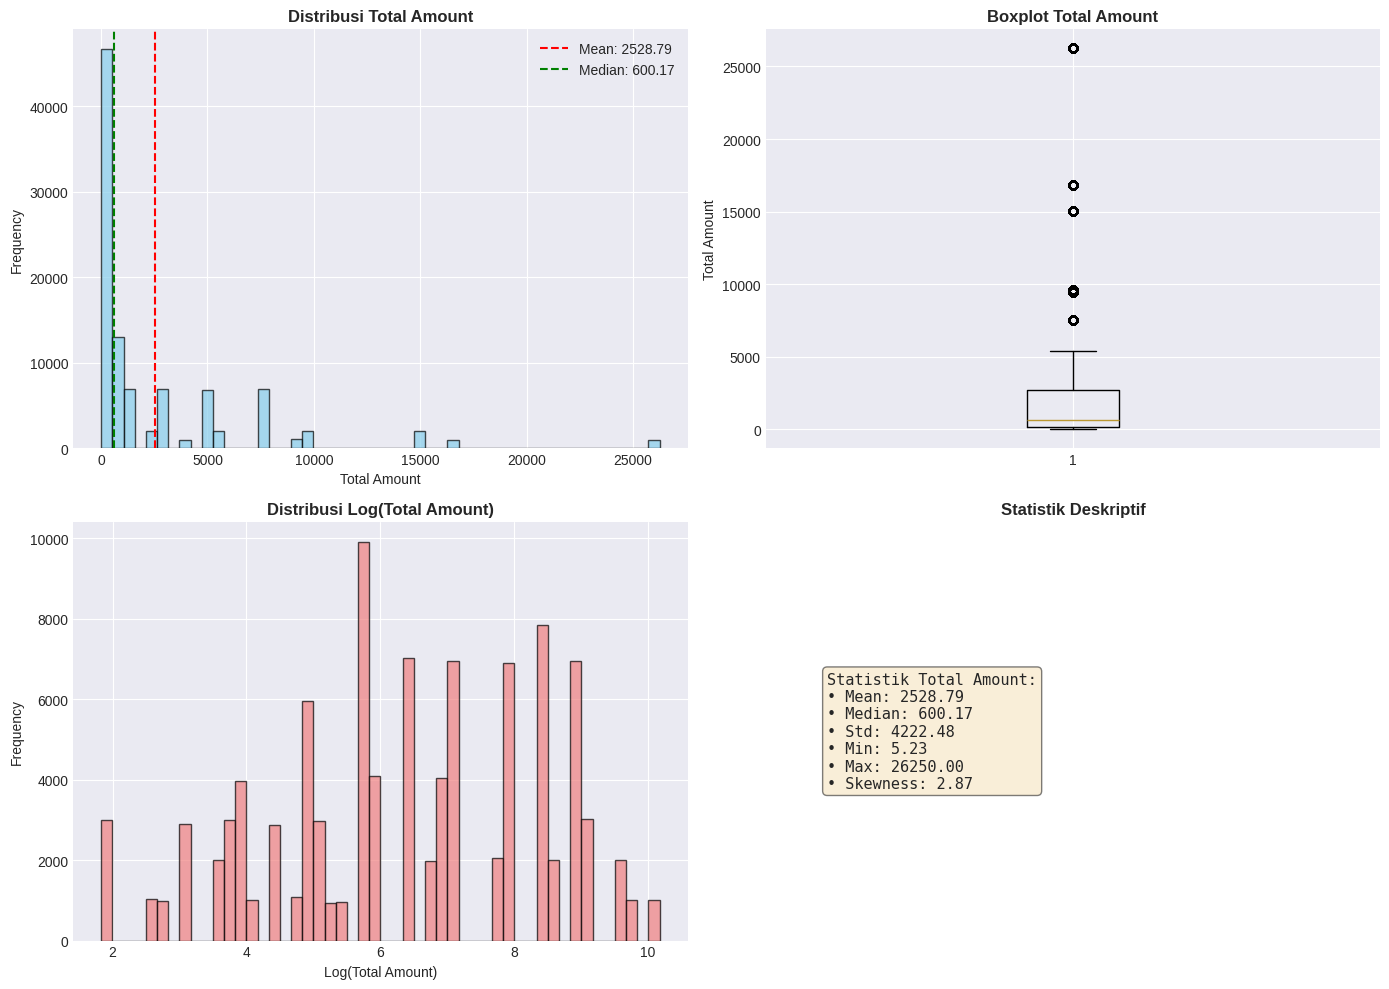

In [41]:
# Visualisasi 1: Distribusi Target Variable (Total Amount)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0,0].hist(df['total_amount'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0,0].set_title('Distribusi Total Amount', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Total Amount')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['total_amount'].mean(), color='red', linestyle='--', label=f'Mean: {df["total_amount"].mean():.2f}')
axes[0,0].axvline(df['total_amount'].median(), color='green', linestyle='--', label=f'Median: {df["total_amount"].median():.2f}')
axes[0,0].legend()

# Boxplot
axes[0,1].boxplot(df['total_amount'])
axes[0,1].set_title('Boxplot Total Amount', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Total Amount')

# Log transform (untuk melihat distribusi yang lebih baik)
axes[1,0].hist(np.log1p(df['total_amount']), bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1,0].set_title('Distribusi Log(Total Amount)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Log(Total Amount)')
axes[1,0].set_ylabel('Frequency')

# Statistics text
stats_text = f"""Statistik Total Amount:
• Mean: {df['total_amount'].mean():.2f}
• Median: {df['total_amount'].median():.2f}
• Std: {df['total_amount'].std():.2f}
• Min: {df['total_amount'].min():.2f}
• Max: {df['total_amount'].max():.2f}
• Skewness: {df['total_amount'].skew():.2f}"""
axes[1,1].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
               fontfamily='monospace', bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
axes[1,1].axis('off')
axes[1,1].set_title('Statistik Deskriptif', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

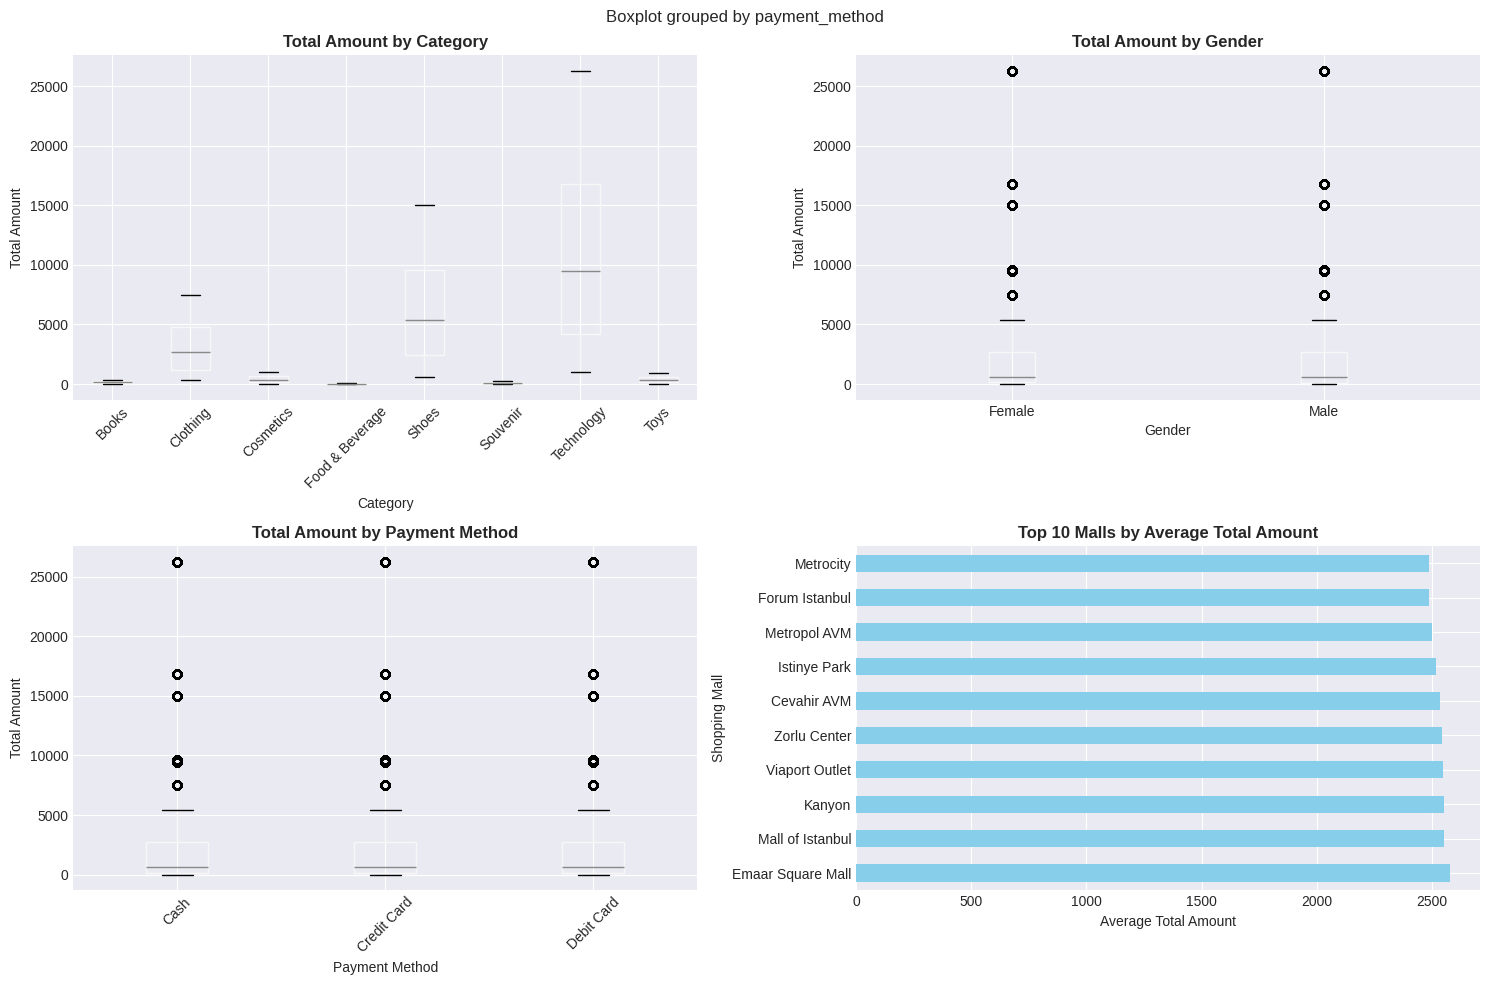

In [42]:
# Visualisasi 2: Analisis berdasarkan kategori
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Category vs Total Amount
category_stats = df.groupby('category')['total_amount'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
top_categories = category_stats.head(8).index
df_top_cat = df[df['category'].isin(top_categories)]
df_top_cat.boxplot(column='total_amount', by='category', ax=axes[0,0])
axes[0,0].set_title('Total Amount by Category', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Total Amount')
axes[0,0].tick_params(axis='x', rotation=45)

# Gender vs Total Amount
df.boxplot(column='total_amount', by='gender', ax=axes[0,1])
axes[0,1].set_title('Total Amount by Gender', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Gender')
axes[0,1].set_ylabel('Total Amount')

# Payment Method vs Total Amount
df.boxplot(column='total_amount', by='payment_method', ax=axes[1,0])
axes[1,0].set_title('Total Amount by Payment Method', fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Payment Method')
axes[1,0].set_ylabel('Total Amount')
axes[1,0].tick_params(axis='x', rotation=45)

# Shopping Mall vs Total Amount (top 10)
mall_stats = df.groupby('shopping_mall')['total_amount'].mean().nlargest(10)
mall_stats.plot(kind='barh', ax=axes[1,1], color='skyblue')
axes[1,1].set_title('Top 10 Malls by Average Total Amount', fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Average Total Amount')
axes[1,1].set_ylabel('Shopping Mall')

plt.tight_layout()
plt.savefig('eda_categorical_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

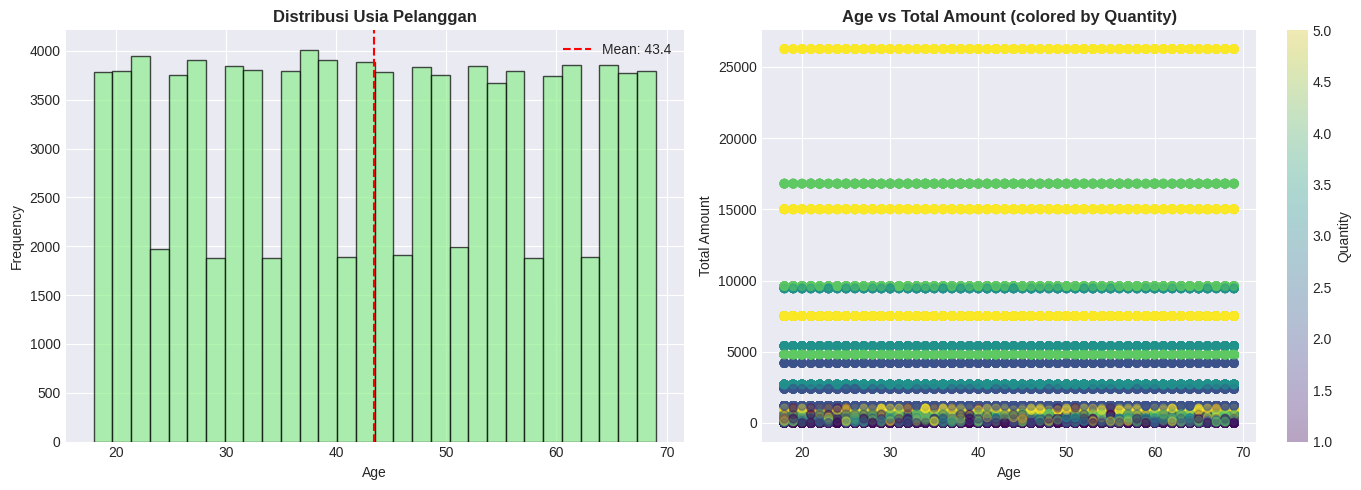

In [43]:
# Visualisasi 3: Analisis numerik dan korelasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df['age'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0].set_title('Distribusi Usia Pelanggan', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0].legend()

# Age vs Total Amount (scatter)
scatter = axes[1].scatter(df['age'], df['total_amount'], alpha=0.3, c=df['quantity'], cmap='viridis')
axes[1].set_title('Age vs Total Amount (colored by Quantity)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Total Amount')
plt.colorbar(scatter, ax=axes[1], label='Quantity')
plt.tight_layout()
plt.savefig('eda_age_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

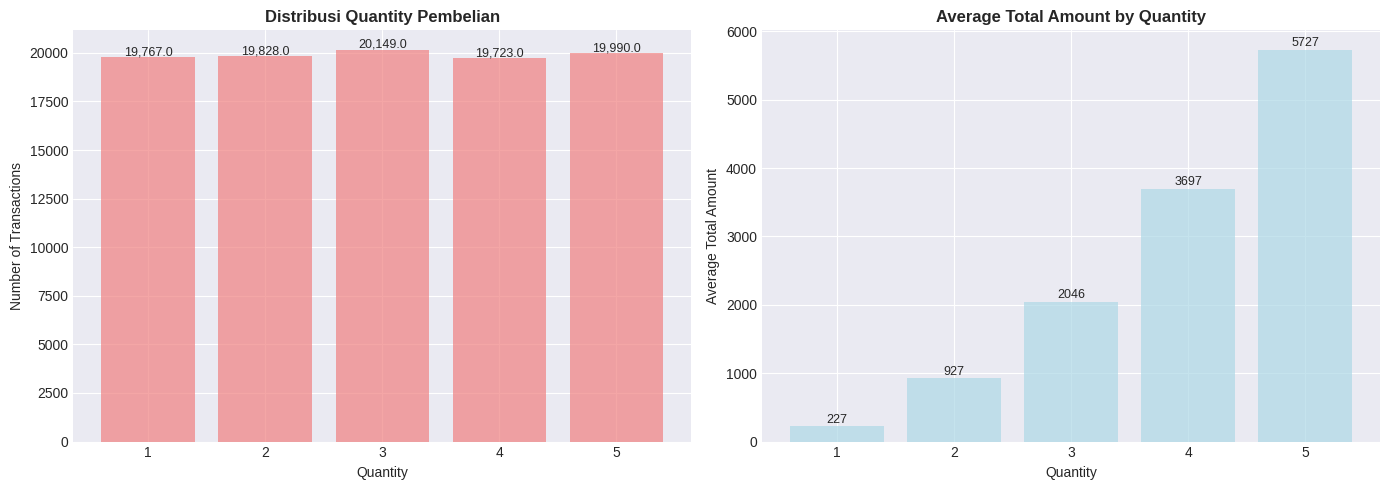

In [44]:
# Visualisasi 4: Korelasi dan Quantity analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantity distribution
quantity_stats = df.groupby('quantity')['total_amount'].agg(['mean', 'count'])
axes[0].bar(quantity_stats.index, quantity_stats['count'], color='lightcoral', alpha=0.7)
axes[0].set_title('Distribusi Quantity Pembelian', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Number of Transactions')
for i, (qty, row) in enumerate(quantity_stats.iterrows()):
    axes[0].text(qty, row['count'] + 100, f'{row["count"]:,}', ha='center', fontsize=9)

# Quantity vs Average Total Amount
axes[1].bar(quantity_stats.index, quantity_stats['mean'], color='lightblue', alpha=0.7)
axes[1].set_title('Average Total Amount by Quantity', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Average Total Amount')
for i, (qty, row) in enumerate(quantity_stats.iterrows()):
    axes[1].text(qty, row['mean'] + 50, f'{row["mean"]:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_quantity_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

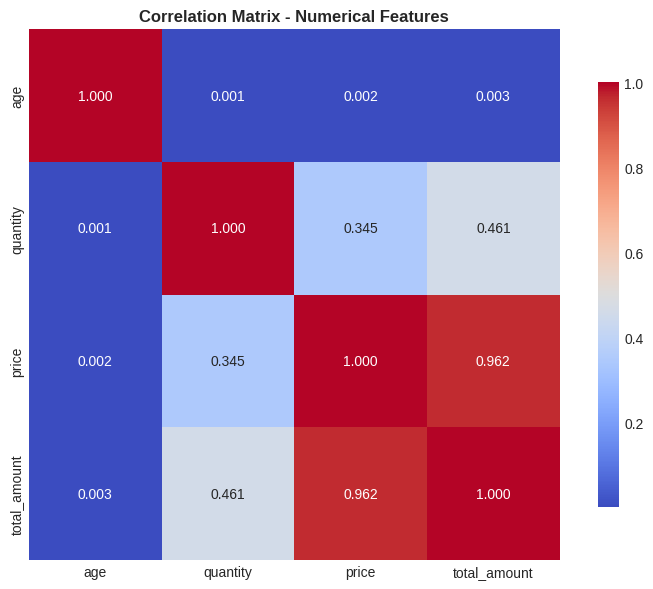


INSIGHT DARI KORELASI:
• Korelasi age dengan Total Amount: 0.003
• Korelasi quantity dengan Total Amount: 0.461
• Korelasi price dengan Total Amount: 0.962


In [45]:
# Korelasi matrix (hanya untuk fitur numerik)
numerical_cols = ['age', 'quantity', 'price', 'total_amount']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("INSIGHT DARI KORELASI:")
print("="*50)
for col in numerical_cols:
    if col != 'total_amount':
        corr = corr_matrix.loc[col, 'total_amount']
        print(f"• Korelasi {col} dengan Total Amount: {corr:.3f}")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [48]:
# Copy dataset untuk preprocessing
df_processed = df.copy()

print("Dataset awal:")
print(f"Shape: {df_processed.shape}")
print(f"Total transaksi: {len(df_processed):,}")
print(f"Unique customers: {df_processed['customer_id'].nunique():,}")

# **TAHAP 1: Drop kolom yang tidak diperlukan untuk modeling**
print("\n" + "="*50)
print("TAHAP 1: MENGHAPUS KOLOM TIDAK PERLU")
print("="*50)

columns_to_drop = ['invoice_no', 'customer_id', 'invoice_date']
df_processed = df_processed.drop(columns=columns_to_drop)
print(f"Kolom yang dihapus: {columns_to_drop}")
print(f"Shape setelah drop: {df_processed.shape}")
print(f"Kolom yang tersisa: {list(df_processed.columns)}")

# **TAHAP 2: Handle Missing Values (jika ada)**
print("\n" + "="*50)
print("TAHAP 2: CEK MISSING VALUES")
print("="*50)
missing_before = df_processed.isnull().sum().sum()
print(f"Missing values sebelum: {missing_before}")

if missing_before > 0:
    for col in df_processed.columns:
        if df_processed[col].isnull().any():
            if df_processed[col].dtype in ['int64', 'float64']:
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
            else:
                df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
    print("Missing values telah diisi!")
else:
    print("Tidak ada missing values!")

# **TAHAP 3: Remove Duplicates**
print("\n" + "="*50)
print("TAHAP 3: MENGHAPUS DATA DUPLIKAT")
print("="*50)
duplicates = df_processed.duplicated().sum()
if duplicates > 0:
    df_processed = df_processed.drop_duplicates()
    print(f"Dihapus {duplicates:,} data duplikat")
    print(f"Shape setelah hapus duplikat: {df_processed.shape}")
else:
    print("Tidak ada data duplikat")

# **TAHAP 4: Handle Outliers (IQR Method)**
print("\n" + "="*50)
print("TAHAP 4: DETEKSI OUTLIER")
print("="*50)

outlier_cols = ['age', 'quantity', 'price', 'total_amount']
outliers_count = {}

for col in outlier_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)]
    outliers_count[col] = len(outliers)
    percentage = (len(outliers) / len(df_processed)) * 100
    print(f"{col}: {len(outliers):,} outliers ({percentage:.2f}%)")

# Capping outliers untuk price dan total_amount
print("\nMelakukan capping outliers untuk price dan total_amount...")
for col in ['price', 'total_amount']:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before_cap = df_processed[col].max()
    df_processed[col] = df_processed[col].clip(lower_bound, upper_bound)
    after_cap = df_processed[col].max()
    print(f"  {col}: max value berubah dari {before_cap:.2f} menjadi {after_cap:.2f}")

# **TAHAP 5: Feature Engineering**
print("\n" + "="*50)
print("TAHAP 5: FEATURE ENGINEERING")
print("="*50)

# Price per category (harga relatif terhadap kategori)
category_price_mean = df_processed.groupby('category')['price'].transform('mean')
df_processed['price_vs_category_avg'] = df_processed['price'] / category_price_mean
print(f"✓ Feature 'price_vs_category_avg' (relative price to category average)")

# **TAHAP 6: Encoding ALL Categorical Variables (SEBELUM scaling)**
print("\n" + "="*50)
print("TAHAP 6: ENCODING KATEGORIKAL")
print("="*50)

# Include 'age_group' setelah dibuat
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal sebelum encoding: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"✓ {col}: encoded dengan {len(le.classes_)} unique values")

# **TAHAP 7: Feature Scaling (SEMUA FITUR SUDAH NUMERIK)**
print("\n" + "="*50)
print("TAHAP 7: FEATURE SCALING")
print("="*50)

# Pisahkan fitur dan target
target_col = 'total_amount'
feature_cols = [col for col in df_processed.columns if col != target_col]

X = df_processed[feature_cols]
y = df_processed[target_col]

# Verifikasi semua kolom sudah numerik
print(f"Verifikasi tipe data:")
for col in X.columns:
    print(f"  {col}: {X[col].dtype}")

# Standard scaling untuk semua fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

# Gabungkan kembali dengan target
df_final = X_scaled_df.copy()
df_final[target_col] = y.values

print(f"✓ Scaling completed dengan StandardScaler")
print(f"  - Mean after scaling: {X_scaled_df.mean().mean():.3f}")
print(f"  - Std after scaling: {X_scaled_df.std().mean():.3f}")

# **TAHAP 8: Split Dataset**
print("\n" + "="*50)
print("TAHAP 8: SPLIT DATASET")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} samples ({len(X_train)/len(df_final)*100:.1f}%)")
print(f"Test set: {len(X_test):,} samples ({len(X_test)/len(df_final)*100:.1f}%)")

# **Final Check**
print("\n" + "="*50)
print("FINAL DATASET AFTER PREPROCESSING:")
print("="*50)
print(f"Shape: {df_final.shape}")
print(f"Missing values: {df_final.isnull().sum().sum()}")
print(f"Duplicates: {df_final.duplicated().sum()}")
print(f"\nFeatures: {list(df_final.columns)}")
print(f"\nTarget: {target_col}")
print(f"\nSample data (5 baris pertama):")
print(df_final.head())

# Simpan hasil preprocessing
df_final.to_csv('customer_shopping_data_preprocessing.csv', index=False)
print("\n✓ Dataset bersih telah disimpan ke 'customer_shopping_data_preprocessing.csv'")

Dataset awal:
Shape: (99457, 11)
Total transaksi: 99,457
Unique customers: 99,457

TAHAP 1: MENGHAPUS KOLOM TIDAK PERLU
Kolom yang dihapus: ['invoice_no', 'customer_id', 'invoice_date']
Shape setelah drop: (99457, 8)
Kolom yang tersisa: ['gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'shopping_mall', 'total_amount']

TAHAP 2: CEK MISSING VALUES
Missing values sebelum: 0
Tidak ada missing values!

TAHAP 3: MENGHAPUS DATA DUPLIKAT
Dihapus 45,257 data duplikat
Shape setelah hapus duplikat: (54200, 8)

TAHAP 4: DETEKSI OUTLIER
age: 0 outliers (0.00%)
quantity: 0 outliers (0.00%)
price: 3,735 outliers (6.89%)
total_amount: 7,484 outliers (13.81%)

Melakukan capping outliers untuk price dan total_amount...
  price: max value berubah dari 5250.00 menjadi 2571.24
  total_amount: max value berubah dari 26250.00 menjadi 6593.45

TAHAP 5: FEATURE ENGINEERING
✓ Feature 'price_vs_category_avg' (relative price to category average)

TAHAP 6: ENCODING KATEGORIKAL
Kolom kategorikal

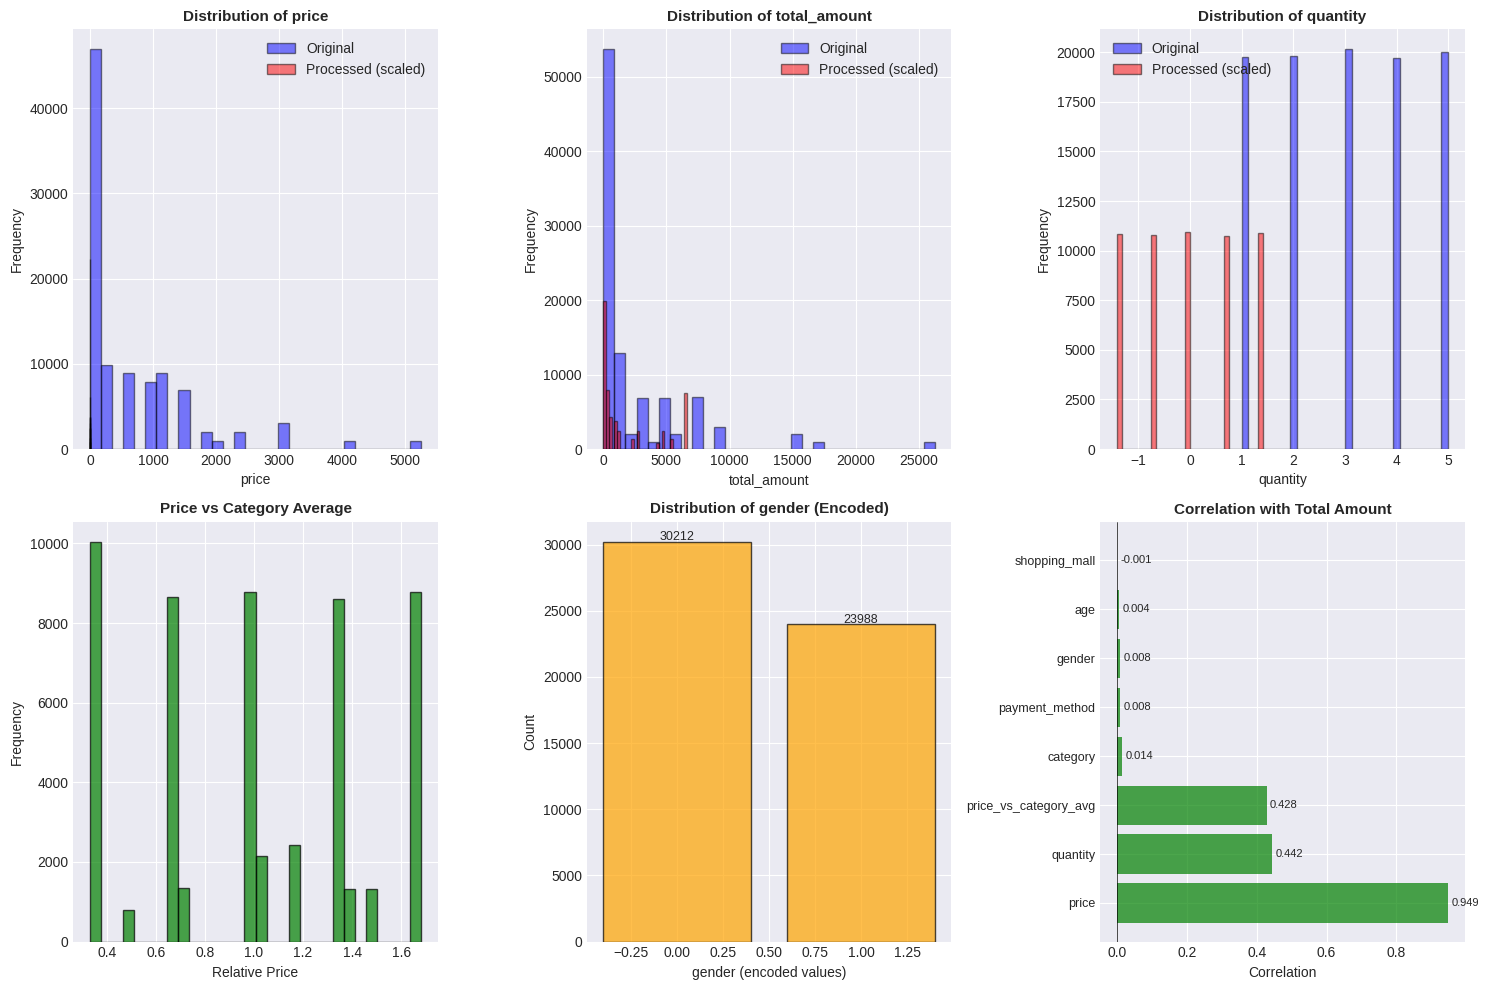


✅ PREPROCESSING SELESAI!
📊 Final dataset shape: (54200, 9)
🎯 Target: total_amount
📝 Total features: 8

Feature list: ['gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'shopping_mall', 'price_vs_category_avg', 'total_amount']

Target statistics:
  - Mean: 1747.066
  - Std: 2368.839
  - Min: 5.230
  - Max: 6593.445

✨ Data siap untuk digunakan dalam training model!


In [49]:
# Summary visualisasi preprocessing
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Before vs After untuk beberapa fitur
features_to_plot = ['price', 'total_amount', 'quantity']

for idx, feature in enumerate(features_to_plot):
    # Plot original (dari df asli)
    axes[0, idx].hist(df[feature], bins=30, alpha=0.5, label='Original', color='blue', edgecolor='black')
    # Plot processed (dari df_final yang sudah discale)
    axes[0, idx].hist(df_final[feature], bins=30, alpha=0.5, label='Processed (scaled)', color='red', edgecolor='black')
    axes[0, idx].set_title(f'Distribution of {feature}', fontweight='bold', fontsize=11)
    axes[0, idx].legend()
    axes[0, idx].set_xlabel(feature)
    axes[0, idx].set_ylabel('Frequency')

# Distribution of price_vs_category_avg (feature baru)
if 'price_vs_category_avg' in df_processed.columns:
    axes[1, 0].hist(df_processed['price_vs_category_avg'], bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Price vs Category Average', fontweight='bold', fontsize=11)
    axes[1, 0].set_xlabel('Relative Price')
    axes[1, 0].set_ylabel('Frequency')
else:
    axes[1, 0].text(0.5, 0.5, 'Feature not available', ha='center', va='center')
    axes[1, 0].set_title('Price vs Category Average', fontweight='bold')

# Distribution of categorical features after encoding (pilih salah satu)
categorical_features = ['gender', 'category', 'payment_method', 'shopping_mall']
feature_to_plot = categorical_features[0]  # Ambil gender sebagai contoh
if feature_to_plot in df_processed.columns:
    value_counts = df_processed[feature_to_plot].value_counts()
    axes[1, 1].bar(range(len(value_counts)), value_counts.values, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 1].set_title(f'Distribution of {feature_to_plot} (Encoded)', fontweight='bold', fontsize=11)
    axes[1, 1].set_xlabel(f'{feature_to_plot} (encoded values)')
    axes[1, 1].set_ylabel('Count')
    # Tambahkan label pada bar
    for i, (idx, val) in enumerate(value_counts.items()):
        axes[1, 1].text(i, val + 100, str(val), ha='center', fontsize=9)
else:
    axes[1, 1].text(0.5, 0.5, 'Categorical feature not available', ha='center', va='center')
    axes[1, 1].set_title('Categorical Distribution', fontweight='bold')

# Correlation with target after preprocessing
corr_with_target = df_final.corr()[target_col].sort_values(ascending=False)
# Hapus korelasi dengan dirinya sendiri (total_amount)
corr_without_target = corr_with_target.drop(target_col)
colors = ['red' if x < 0 else 'green' for x in corr_without_target.values]
axes[1, 2].barh(range(len(corr_without_target)), corr_without_target.values, color=colors, alpha=0.7)
axes[1, 2].set_yticks(range(len(corr_without_target)))
axes[1, 2].set_yticklabels(corr_without_target.index, fontsize=9)
axes[1, 2].set_title('Correlation with Total Amount', fontweight='bold', fontsize=11)
axes[1, 2].set_xlabel('Correlation')
axes[1, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Tambahkan nilai korelasi pada bar
for i, (idx, value) in enumerate(corr_without_target.items()):
    axes[1, 2].text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('preprocessing_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("✅ PREPROCESSING SELESAI!")
print("="*50)
print(f"📊 Final dataset shape: {df_final.shape}")
print(f"🎯 Target: {target_col}")
print(f"📝 Total features: {len(feature_cols)}")
print(f"\nFeature list: {list(df_final.columns)}")
print(f"\nTarget statistics:")
print(f"  - Mean: {df_final[target_col].mean():.3f}")
print(f"  - Std: {df_final[target_col].std():.3f}")
print(f"  - Min: {df_final[target_col].min():.3f}")
print(f"  - Max: {df_final[target_col].max():.3f}")
print("\n✨ Data siap untuk digunakan dalam training model!")